In [1]:
import os
import sys
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Füge das Projekt-Hauptverzeichnis (zwei Ebenen höher: '../..') hinzu
sys.path.append(os.path.abspath(os.path.join('../..')))
sys.path.append(os.path.abspath(os.path.join('..')))  # <- Das hier wurde hinzugefügt!

# Jetzt über das "python"-Package importieren
from python.evaluation.metrics import calculate_pretreatment_fit, calculate_ground_truth_effect
from python.evaluation.visualization import plot_fit_joint_contour, plot_transport_comparison
from python.temp import get_continuous_data
from python.tea import disco_tea

ModuleNotFoundError: No module named 'python.temp.data'

In [40]:
results_energy = joblib.load('../results/disco_energy.pkl')
results_swasserstein = joblib.load('../results/disco_swasserstein.pkl')
results_mixture = joblib.load('../results/disco_mixture.pkl')
results_tangential = joblib.load('../results/disco_tangential.pkl')

results = [results_energy, results_swasserstein, results_mixture, results_tangential]

In [41]:
metrics_energy = calculate_pretreatment_fit(results_energy)
metrics_swasserstein = calculate_pretreatment_fit(results_swasserstein)
metrics_mixture = calculate_pretreatment_fit(results_mixture)
metrics_tangential = calculate_pretreatment_fit(results_tangential)

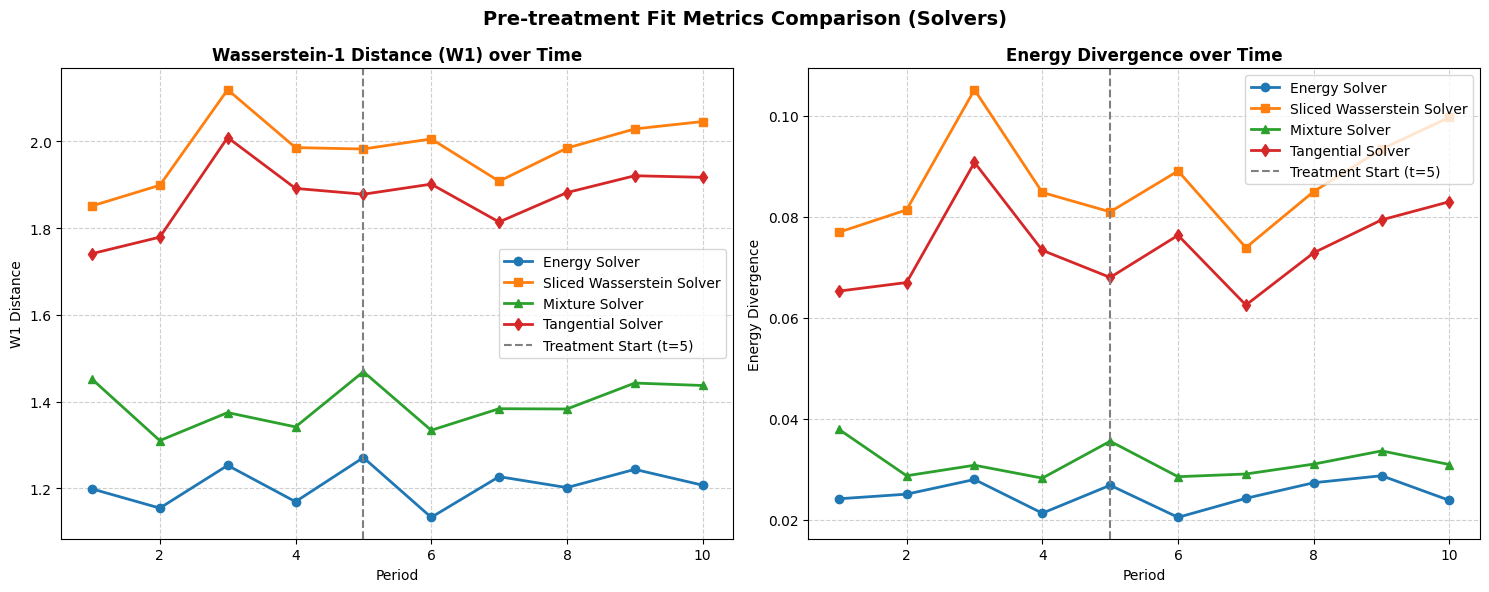

In [42]:
# Perioden auslesen (sind für alle Metriken gleich)
periods = sorted(list(metrics_energy.metrics_per_period.keys()))

# t0-Index (Start der Treatment-Periode) aus den Parametern holen
t0_idx = results_energy.params.t0_idx

# Hilfsfunktion zum Extrahieren der Metriken über alle Perioden
def extract_metric(metrics_obj, metric_name):
    return [metrics_obj.metrics_per_period[t][metric_name] for t in periods]

# Daten für alle 4 Solver zusammenstellen
data = {
    'Period': periods,
    'Energy (W1)': extract_metric(metrics_energy, 'w1'),
    'Energy (Energy Div)': extract_metric(metrics_energy, 'energy_divergence'),
    'Sliced Wasserstein (W1)': extract_metric(metrics_swasserstein, 'w1'),
    'Sliced Wasserstein (Energy Div)': extract_metric(metrics_swasserstein, 'energy_divergence'),
    'Mixture (W1)': extract_metric(metrics_mixture, 'w1'),
    'Mixture (Energy Div)': extract_metric(metrics_mixture, 'energy_divergence'),
    'Tangential (W1)': extract_metric(metrics_tangential, 'w1'),
    'Tangential (Energy Div)': extract_metric(metrics_tangential, 'energy_divergence')
}
df = pd.DataFrame(data)

# Grid-Layout erstellen (2 Subplots nebeneinander)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# 1. Plot: Wasserstein-1-Distanz (W1)
axes[0].plot(df['Period'], df['Energy (W1)'], label='Energy Solver', color='#1f77b4', marker='o', linewidth=2)
axes[0].plot(df['Period'], df['Sliced Wasserstein (W1)'], label='Sliced Wasserstein Solver', color='#ff7f0e', marker='s', linewidth=2)
axes[0].plot(df['Period'], df['Mixture (W1)'], label='Mixture Solver', color='#2ca02c', marker='^', linewidth=2)
axes[0].plot(df['Period'], df['Tangential (W1)'], label='Tangential Solver', color='#d62728', marker='d', linewidth=2)
axes[0].axvline(x=t0_idx + 1, color='grey', linestyle='--', label=f'Treatment Start (t={t0_idx + 1})', linewidth=1.5)
axes[0].set_title('Wasserstein-1 Distance (W1) over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Period', fontsize=10)
axes[0].set_ylabel('W1 Distance', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='best', frameon=True)

# 2. Plot: Energy Divergence
axes[1].plot(df['Period'], df['Energy (Energy Div)'], label='Energy Solver', color='#1f77b4', marker='o', linewidth=2)
axes[1].plot(df['Period'], df['Sliced Wasserstein (Energy Div)'], label='Sliced Wasserstein Solver', color='#ff7f0e', marker='s', linewidth=2)
axes[1].plot(df['Period'], df['Mixture (Energy Div)'], label='Mixture Solver', color='#2ca02c', marker='^', linewidth=2)
axes[1].plot(df['Period'], df['Tangential (Energy Div)'], label='Tangential Solver', color='#d62728', marker='d', linewidth=2)
axes[1].axvline(x=t0_idx + 1, color='grey', linestyle='--', label=f'Treatment Start (t={t0_idx + 1})', linewidth=1.5)
axes[1].set_title('Energy Divergence over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Period', fontsize=10)
axes[1].set_ylabel('Energy Divergence', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='best', frameon=True)

plt.suptitle('Pre-treatment Fit Metrics Comparison (Solvers)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [43]:
print(f'Min p-value {1/(results[0].perm.J_1 + 1)}')
for result in results:
    print(f'p-Value {result.perm.p_overall}')


Min p-value 0.038461538461538464
p-Value 0.6153846153846154
p-Value 0.6923076923076923
p-Value 0.3076923076923077
p-Value 0.8076923076923077


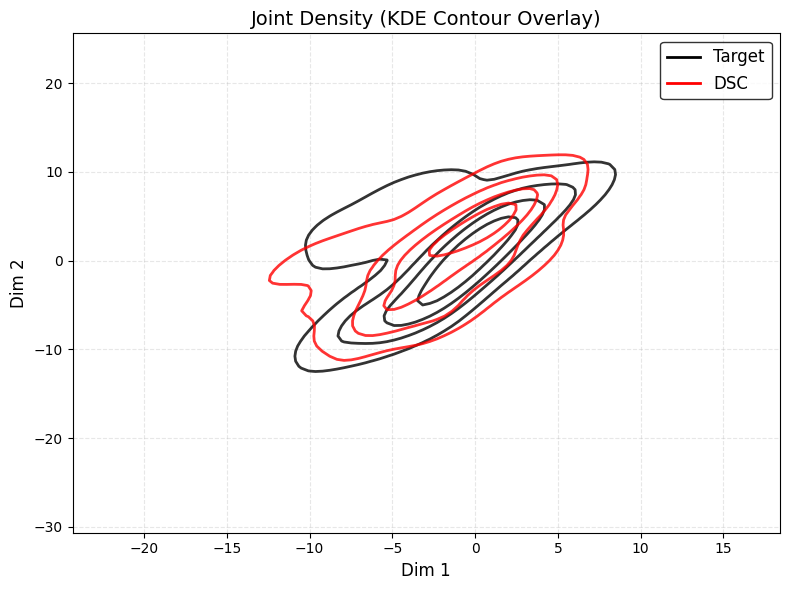

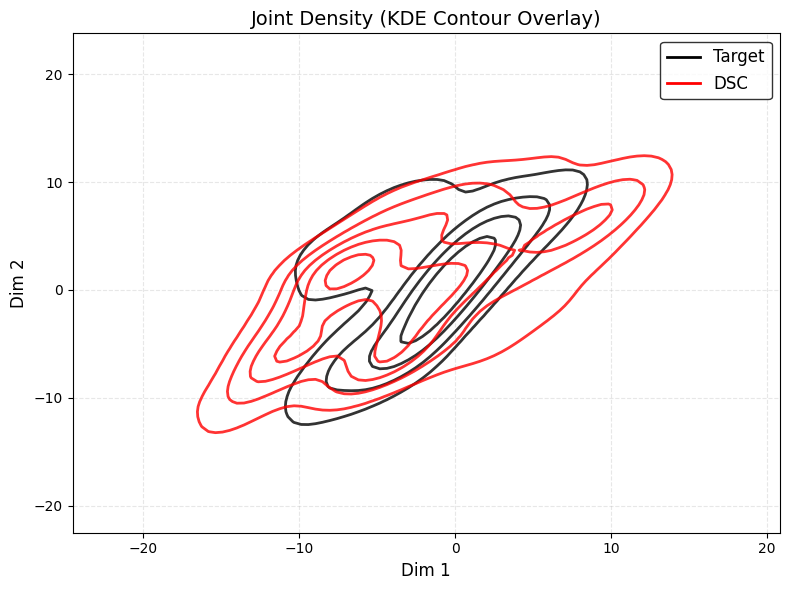

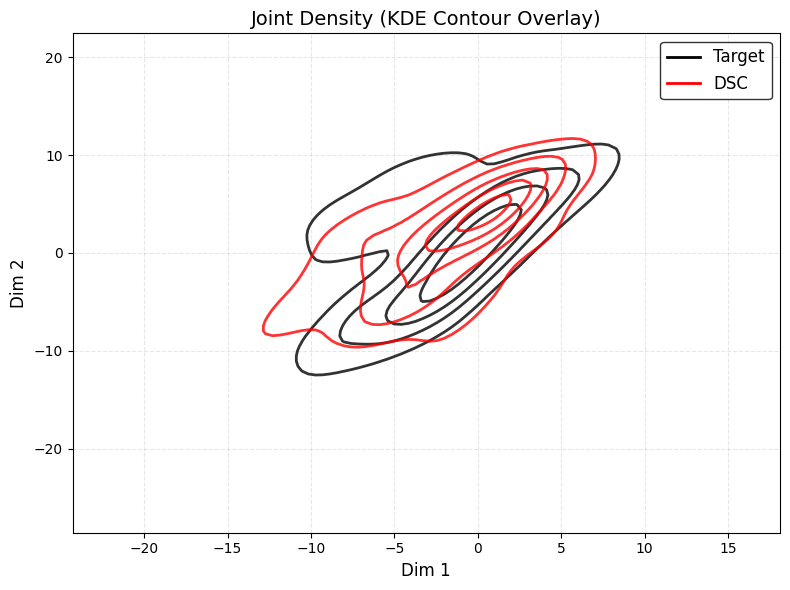

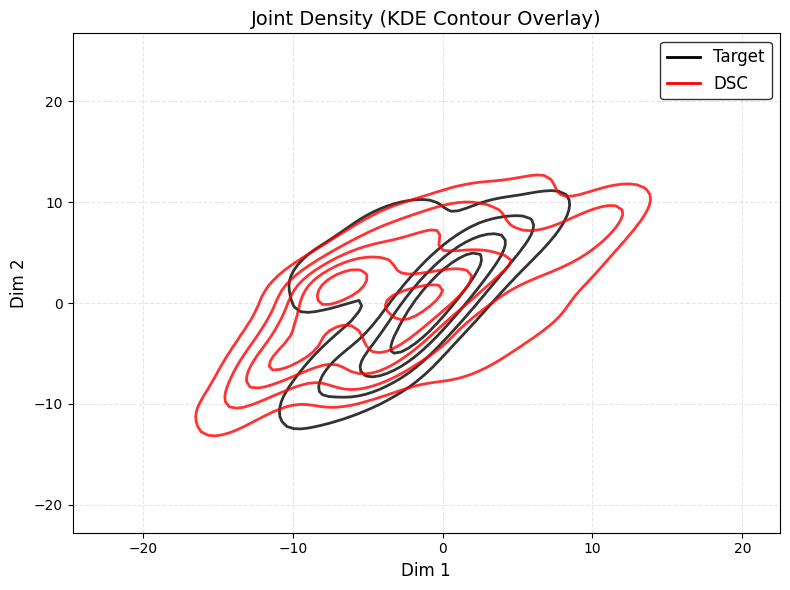

In [44]:
for res in results:
    plot_fit_joint_contour(res, period=4)

## Real Effect

Generated with seed = 16

In [69]:
result_treat = joblib.load('../results/disco_tangential_te.pkl')
#tea = disco_tea(result_treat, agg='transport_map')
#joblib.dump(tea, '../results/energy_effect.pkl')
tea = joblib.load('../results/tangential_effect.pkl')

In [70]:
data = result_treat.params.df.copy()
gt_effect = calculate_ground_truth_effect(data, target_id='0', time_col='time_col', y_cols=['y_col_1','y_col_2'], cf_cols=['y_col_1_cf','y_col_2_cf'])

In [71]:
print(f'Minimal p-value: {1/(result_treat.perm.J_1+1):.4f}')
print(f'Actual  p-value: {result_treat.perm.p_overall:.4f}')

Minimal p-value: 0.0385
Actual  p-value: 0.0385


In [72]:
model = result_treat
dist_mat = result_treat.perm.distp.copy()

dist_df = pd.DataFrame(dist_mat, columns=[f'Period {i+1}' for i in range(dist_mat.shape[1])], index=[f'Control {i+1}' for i in range(dist_mat.shape[0])])
dist_df.reset_index(inplace=True)
dist_df.rename(columns={'index': 'Unit'}, inplace=True)
dist_df = pd.concat([dist_df, pd.DataFrame({'Unit': ['Treated'], **{f'Period {i+1}': model.perm.distt[i] for i in range(model.perm.distt.shape[0])}})], ignore_index=True)
dist_df = pd.concat([dist_df, pd.DataFrame({'Unit': ['Counterfactual'], **{f'Period {i}': gt_effect[i]['w2'] for i in gt_effect.keys()}})], ignore_index=True)

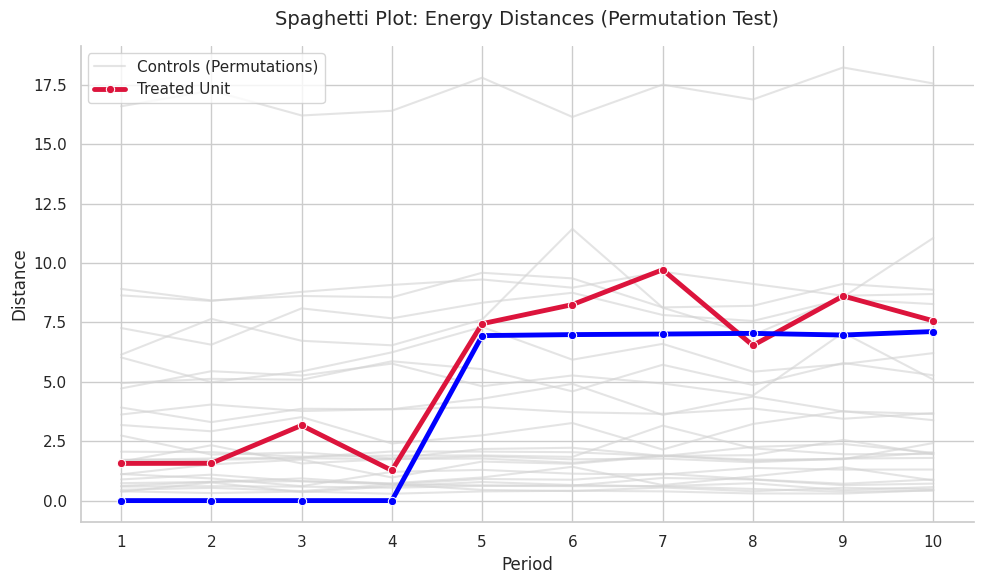

In [73]:
df_long = pd.melt(
    dist_df, id_vars=["Unit"], var_name="Period", value_name="Distance"
)

# Optional: 'Period 1', 'Period 2' zu reinen Zahlen (1, 2) machen, damit die X-Achse sauber sortiert ist
df_long["Period_Num"] = (
    df_long["Period"].str.replace("Period ", "").astype(int)
)

# --- 2. Plot erstellen ---
plt.figure(figsize=(10, 6), dpi=100)

# Hintergrund: Alle Kontrollgruppen (Grau und dünn)
controls = df_long[df_long["Unit"] != "Treated"]
sns.lineplot(
    data=controls,
    x="Period_Num",
    y="Distance",
    units="Unit",  # Wichtig! Zeichnet für jede Unit eine eigene Linie
    estimator=None,  # Verhindert das Aggregieren/Mitteln der Daten
    color="lightgray",
    alpha=0.6,
    linewidth=1.5,
    label="Controls (Permutations)",
)

# Vordergrund: Die behandelte Einheit (Blau/Rot und dick)
treated = df_long[df_long["Unit"] == "Treated"]
sns.lineplot(
    data=treated,
    x="Period_Num",
    y="Distance",
    color="crimson",  # Schön sichtbares Rot für die Thesis
    linewidth=3.5,
    marker="o",  # Punkte auf den Perioden
    label="Treated Unit",
)
if True:
    counterfactual = df_long[df_long["Unit"] == "Counterfactual"]
    sns.lineplot(
        data=counterfactual,
        x="Period_Num",
        y="Distance",
        color="blue",  # Schön sichtbares Rot für die Thesis
        linewidth=3.5,
        marker="o",  # Punkte auf den Perioden
        label="Counterfactual",
    )

# --- 3. Styling & Beschriftung ---
plt.title(
    "Spaghetti Plot: Energy Distances (Permutation Test)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Period", fontsize=12)
plt.ylabel("Distance", fontsize=12)

# X-Achsen-Ticks sauber beschriften (jede Periode eine Zahl)
plt.xticks(np.arange(1, dist_mat.shape[1] + 1))

# Legende aufräumen (da 'controls' sonst für jede einzelne Unit ein Label erzeugen will)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(
    [by_label["Controls (Permutations)"], by_label["Treated Unit"]],
    ["Controls (Permutations)", "Treated Unit"],
    loc="upper left",
)

sns.despine()  # Entfernt den oberen und rechten Rahmen für einen cleanen Look
plt.tight_layout()
plt.show()

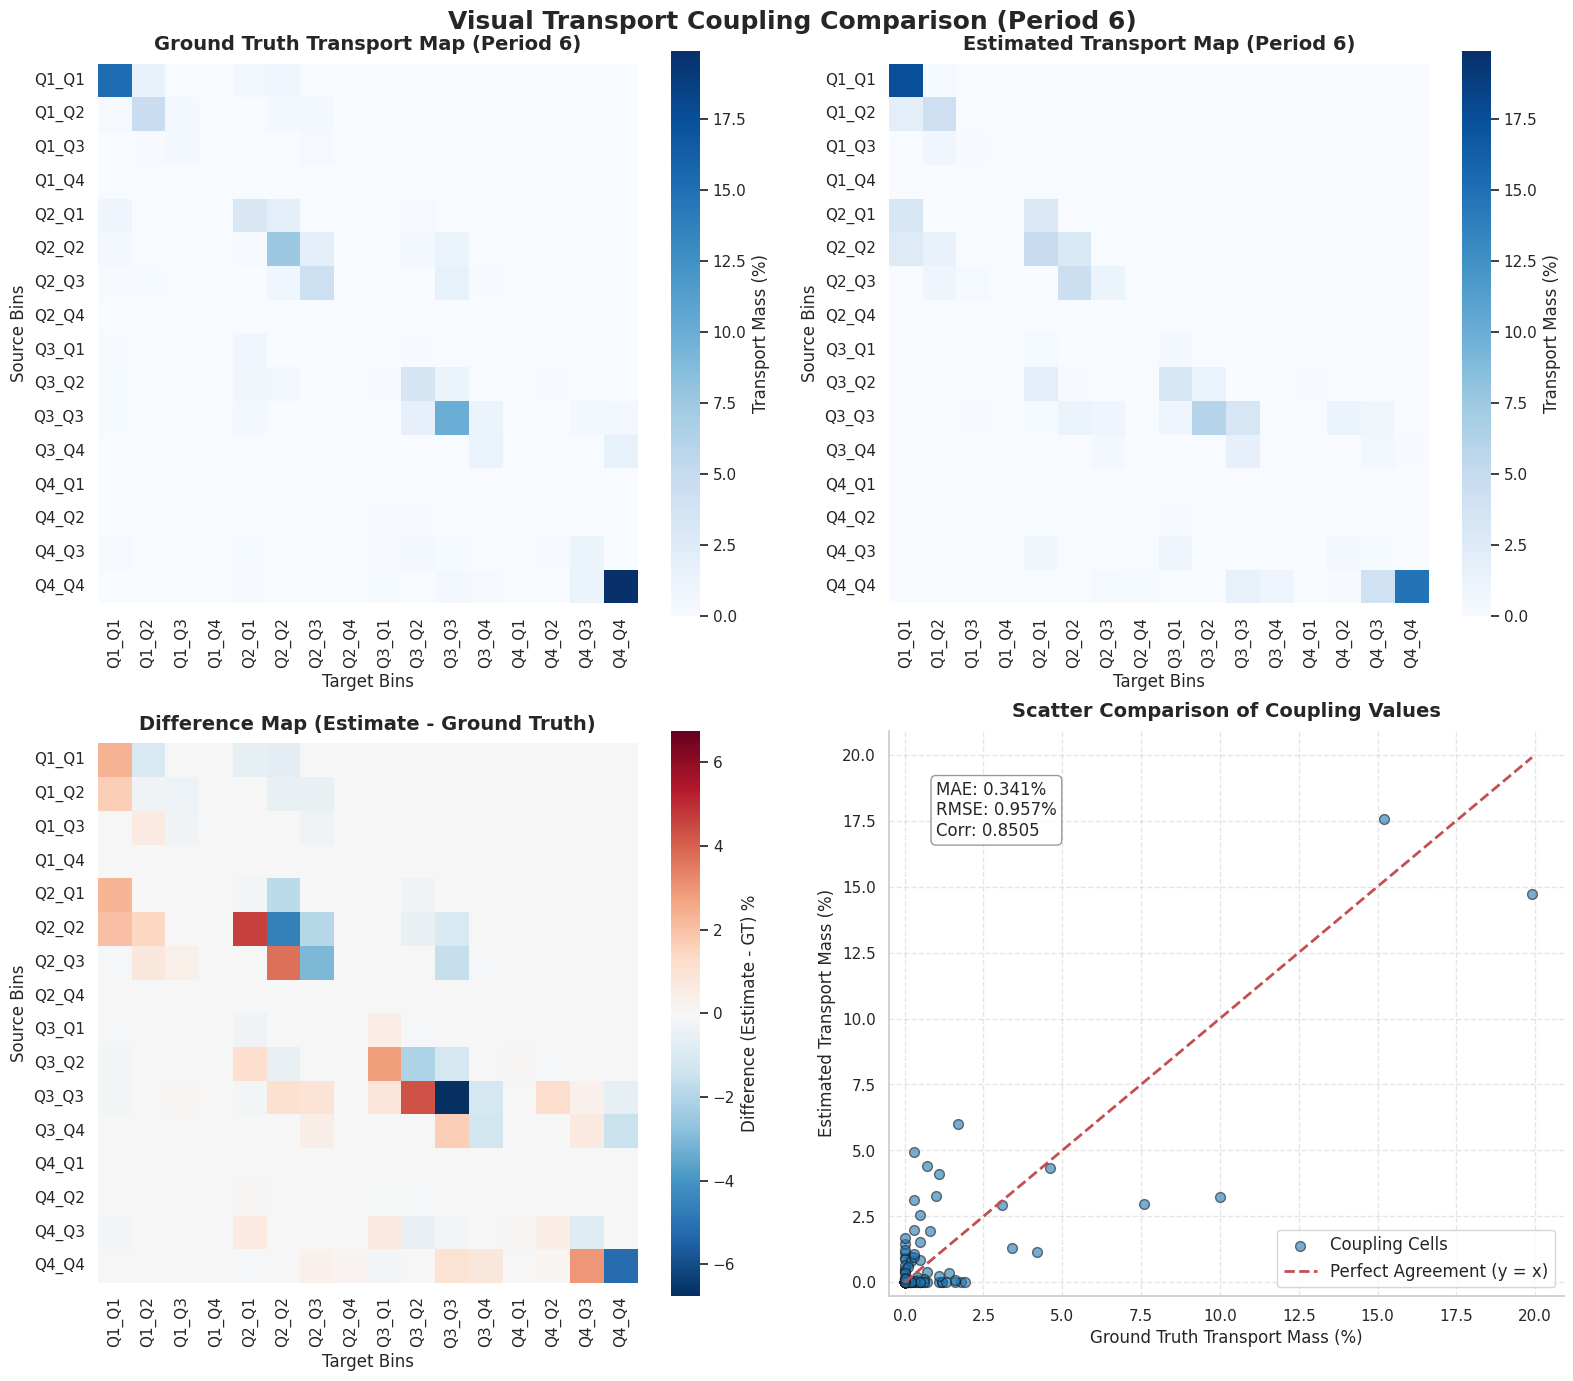

In [64]:
from python.evaluation.visualization import plot_transport_comparison

# Visual comparison of GT Effect and Estimate for period 5
plot_transport_comparison(gt_effect, tea, period=6)

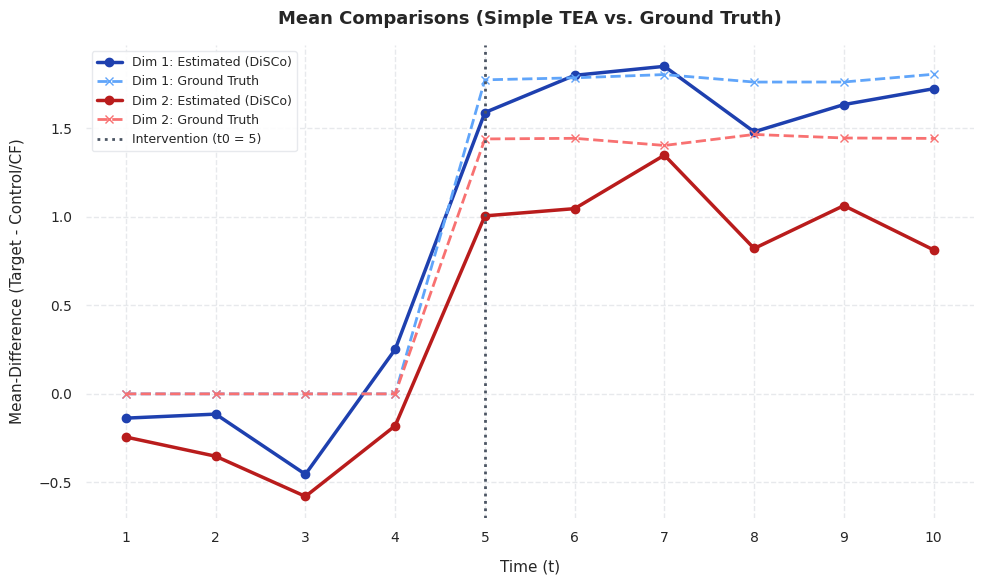

In [65]:
simple_tea = disco_tea(result_treat, agg='simple')

# Modernes Styling aktivieren
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Inter']

# 1. Daten und Perioden extrahieren
periods = sorted(list(simple_tea.treats.keys()))
t0 = simple_tea.t0

# Konvertierung zu Arrays
est_mean_diff = np.asarray([simple_tea.treats[t]['mean_diff'] for t in periods])
gt_mean_diff = np.asarray([gt_effect[t]['mean_diff'] for t in periods])

# Plot initialisieren
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Farbpalette für die Dimensionen (Sleek Indigo/Blue für Dim 1, Crimson/Rose für Dim 2)
colors_dim1 = {"est": "#1E40AF", "gt": "#60A5FA"}  # Dunkelblau / Hellblau
colors_dim2 = {"est": "#B91C1C", "gt": "#F87171"}  # Dunkelrot / Hellrot

# --- Dimension 1 ---
ax.plot(periods, est_mean_diff[:, 0], color=colors_dim1["est"], linewidth=2.5, 
        marker='o', markersize=6, label="Dim 1: Estimated (DiSCo)")
ax.plot(periods, gt_mean_diff[:, 0], color=colors_dim1["gt"], linewidth=2.0, 
        linestyle='--', marker='x', markersize=6, label="Dim 1: Ground Truth")

# --- Dimension 2 ---
ax.plot(periods, est_mean_diff[:, 1], color=colors_dim2["est"], linewidth=2.5, 
        marker='o', markersize=6, label="Dim 2: Estimated (DiSCo)")
ax.plot(periods, gt_mean_diff[:, 1], color=colors_dim2["gt"], linewidth=2.0, 
        linestyle='--', marker='x', markersize=6, label="Dim 2: Ground Truth")

# --- Interventionslinie (t0) ---
ax.axvline(x=t0, color="#4B5563", linestyle=":", linewidth=2, 
           label=f"Intervention (t0 = {t0})")

# Labels und Titel
ax.set_title("Mean Comparisons (Simple TEA vs. Ground Truth)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Time (t)", fontsize=11, labelpad=10)
ax.set_ylabel("Mean-Difference (Target - Control/CF)", fontsize=11, labelpad=10)

# Styling der Achsen und Grids
ax.set_xticks(periods)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(True, linestyle="--", alpha=0.5, color="#D1D5DB")

# Legende
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#E5E7EB", framealpha=0.9, fontsize=9)

# Rahmenlinien (Spines) dezent entfernen für einen flachen Look
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


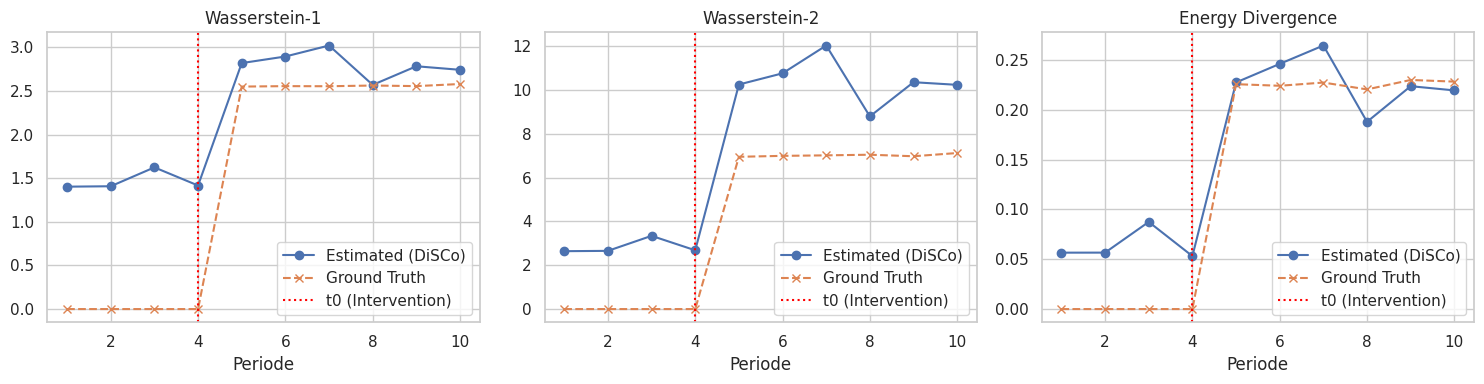

In [66]:
import matplotlib.pyplot as plt
from python.evaluation.metrics import calculate_pretreatment_fit

# 1. Berechne geschätzte Distanzen (DiSCo)
fit_metrics = calculate_pretreatment_fit(result_treat)
est_metrics = fit_metrics.metrics_per_period

# 2. Extrahiere GT-Distanzen
periods = sorted(list(est_metrics.keys()))
t0 = result_treat.params.t0_idx

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['w1', 'w2', 'energy_divergence']
titles = ['Wasserstein-1', 'Wasserstein-2', 'Energy Divergence']

for i, m in enumerate(metrics):
    est_vals = [est_metrics[t][m] for t in periods]
    gt_vals = [gt_effect[t][m] for t in periods]
    
    axes[i].plot(periods, est_vals, marker='o', label='Estimated (DiSCo)')
    axes[i].plot(periods, gt_vals, marker='x', linestyle='--', label='Ground Truth')
    axes[i].axvline(x=t0, color='red', linestyle=':', label='t0 (Intervention)')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Periode')
    axes[i].legend()

plt.tight_layout()
plt.show()


In [31]:
import joblib
joblib.load('../results/effects/mc_teas_energy.pkl')

ModuleNotFoundError: No module named 'python'